# Task 3 — Gender and Usage Classification

**Status:** the fixed primary baseline has completed all five folds for both targets.
This notebook now records the model, pooled evidence, diagnosis, and next hypotheses.

**Owner:** TODO(owner)


## Colab setup — repository and teacher data

Run these cells at the start of each fresh Colab runtime. They are safe to rerun.
The repository supplies `data/processed`, including the one allowed split. The Drive
archive supplies only `data/raw/teacher`. Images are extracted to Colab's local disk
because training directly from Drive is much slower.


In [24]:
from pathlib import Path
import os
import subprocess
import sys
import zipfile

REPO_URL = "https://github.com/TrnLin/MLA2.git"
BRANCH = "task-3-gender-usage-classification"
REPO_DIR = Path("/content/MLA2")
DRIVE_MOUNT = Path("/content/drive")
DRIVE_PROJECT_DIR = DRIVE_MOUNT / "MyDrive/MLA2"
DATA_ZIP = DRIVE_PROJECT_DIR / "data/task3-data.zip"
DRIVE_TASK_DIR = DRIVE_PROJECT_DIR / "task3"


def run_checked(command, *, cwd=None):
    command = [str(part) for part in command]
    print("$", " ".join(command))
    return subprocess.run(command, cwd=cwd, check=True)


In [25]:
try:
    from google.colab import drive
except ImportError as exc:
    raise RuntimeError("This setup cell must run in Google Colab.") from exc

drive.mount(str(DRIVE_MOUNT), force_remount=False)

if (REPO_DIR / ".git").is_dir():
    remote_url = subprocess.check_output(
        ["git", "remote", "get-url", "origin"], cwd=REPO_DIR, text=True
    ).strip()
    if remote_url != REPO_URL:
        raise RuntimeError(f"{REPO_DIR} belongs to a different repository: {remote_url}")
    run_checked(["git", "fetch", "origin", BRANCH], cwd=REPO_DIR)
    run_checked(["git", "switch", BRANCH], cwd=REPO_DIR)
    dirty = subprocess.check_output(
        ["git", "status", "--porcelain"], cwd=REPO_DIR, text=True
    ).strip()
    if dirty:
        print("Local repository changes found; skipped the automatic fast-forward update.")
    else:
        run_checked(["git", "merge", "--ff-only", f"origin/{BRANCH}"], cwd=REPO_DIR)
elif REPO_DIR.exists():
    raise RuntimeError(f"{REPO_DIR} exists but is not a Git repository.")
else:
    run_checked(
        ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, REPO_DIR]
    )

print(f"Repository ready: {REPO_DIR} ({BRANCH})")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
$ git fetch origin task-3-gender-usage-classification
$ git switch task-3-gender-usage-classification
Local repository changes found; skipped the automatic fast-forward update.
Repository ready: /content/MLA2 (task-3-gender-usage-classification)


In [26]:
if not DATA_ZIP.is_file():
    raise FileNotFoundError(
        f"Dataset archive not found at {DATA_ZIP}. Check the Drive folder and file name."
    )

teacher_dir = REPO_DIR / "data/raw/teacher"
required_files = (
    teacher_dir / "train/styles_train.csv",
    teacher_dir / "test/styles_prediction.csv",
)

with zipfile.ZipFile(DATA_ZIP) as archive:
    names = archive.namelist()
    unsafe_names = [
        name for name in names if Path(name).is_absolute() or ".." in Path(name).parts
    ]
    if unsafe_names:
        raise RuntimeError("The dataset archive contains an unsafe path.")
    expected_images = sum(
        name.startswith("data/raw/teacher/") and name.lower().endswith((".jpg", ".jpeg"))
        for name in names
    )
    if expected_images == 0:
        raise RuntimeError("The archive does not contain teacher images in the expected layout.")

    current_images = sum(1 for path in teacher_dir.rglob("*") if path.suffix.lower() in {".jpg", ".jpeg"})
    needs_extract = current_images != expected_images or not all(path.is_file() for path in required_files)
    if needs_extract:
        print(f"Extracting {expected_images:,} teacher images from Drive...")
        archive.extractall(REPO_DIR)
    else:
        print("Teacher data is already extracted; skipping.")

actual_images = sum(1 for path in teacher_dir.rglob("*") if path.suffix.lower() in {".jpg", ".jpeg"})
missing_files = [str(path) for path in required_files if not path.is_file()]
if actual_images != expected_images or missing_files:
    raise RuntimeError(
        f"Dataset check failed: expected {expected_images:,} images, found {actual_images:,}; "
        f"missing files: {missing_files}"
    )

print(f"Teacher data ready: {actual_images:,} images in {teacher_dir}")


Teacher data is already extracted; skipping.
Teacher data ready: 44,441 images in /content/MLA2/data/raw/teacher


In [27]:
os.chdir(REPO_DIR)
os.environ["FASHION_PROJECT_ROOT"] = str(REPO_DIR)
source_dir = str(REPO_DIR / "src")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

for output_dir in (
    DRIVE_TASK_DIR / "checkpoints",
    DRIVE_TASK_DIR / "logs",
    DRIVE_TASK_DIR / "results",
):
    output_dir.mkdir(parents=True, exist_ok=True)

from fashion.data import get_samples, load_label_maps, load_splits

splits = load_splits()
label_maps = load_label_maps()
gender_development = get_samples(splits, partition="development", target="gender")
usage_development = get_samples(splits, partition="development", target="usage")

print("Task 3 data is ready.")
print(f"Gender development rows: {len(gender_development):,}")
print(f"Usage development rows:  {len(usage_development):,}")
print(f"Persistent outputs:       {DRIVE_TASK_DIR}")
splits.groupby("partition", observed=True).size().rename("rows").to_frame()


Task 3 data is ready.
Gender development rows: 32,773
Usage development rows:  32,772
Persistent outputs:       /content/drive/MyDrive/MLA2/task3


,rows
partition,
development,32773
holdout,5778
quarantine,61


## 1. Task contract

- Decision: suggest the supplied catalogue target-audience and usage labels from one teacher image.
- Prediction unit: one teacher catalogue image and product ID.
- Outputs: separate `gender` and `usage` labels. The merged official file remains
  `id,gender,articleType,season,usage`.
- In scope: catalogue-assistance suggestions, confidence review, and assignment predictions.
- Out of scope: person identity or gender inference, customer profiling, access, pricing, or
  another high-impact decision.
- Owner and approval date: TODO(owner).


## 2. EDA evidence and method roles

The primary baseline is derived from the saved Notebook 01 evidence, not from a model-name list.
The evidence fixes the following boundaries:

- 32,773 development products form 22,905 family-safe groups, so all model evidence uses the
  five saved family folds rather than a new random split;
- almost all images are 60×80 and only 12 have unusual dimensions, so the baseline uses the
  native `(height=80, width=60)` information instead of inventing detail by upscaling;
- the contact sheet shows one main product at varying sizes and positions, so shared local
  filters and a position-light whole-image summary are appropriate;
- small visible cues include straps, collars, sleeves, shoe outlines, and fabric boundaries, so
  the feature extractor must preserve several spatial regions instead of reducing immediately
  to one global vector;
- 294 grayscale images remain valid and sampled brightness varies strongly, so every image
  converts to RGB and each fold fits its own content-pixel mean and standard deviation;
- the transform-risk figure shows that stretch changes shape and centre crop can remove edge
  content, so only unusual images use aspect-preserving letterbox resize;
- gender ranges from 17,753 examples in its largest class to 543 in its smallest; usage ranges
  from 25,151 `Casual` examples to one `Home` example, so the first loss stays unweighted and
  macro-F1 exposes minority collapse;
- one usage value is truly blank, literal `NA` is a real class, and only 26 of 45 possible
  gender–usage pairs occur, so the two targets start as separate masked models;
- article type agrees with about 78.5% of gender and 90.0% of usage labels under a descriptive
  majority lookup. It is therefore an error slice and shortcut warning, never a model input.

| Role | Method | Purpose |
|---|---|---|
| Lower bounds | Fold-training majority and stratified predictors | Check priors, metrics, masks, and seeds |
| Integrity checks | Bias-only, shuffled-label, tiny-batch overfit | Find broken code or leakage |
| Classical reference | Exact HOG + HSV logistic regression | Measure hand-built shape and colour |
| Primary learnable baseline | Exact small scratch CNN, trained separately per target | Start the parent-child chain |


## 3. Data, masks, and five-fold contract

- Sole split: `data/processed/splits.csv`. Do not create another split.
- CV mode: all five saved family-safe folds.
- OOF rule: every valid development image is predicted once by a model that did not train on
  its fold or family.
- Teacher images only. Optional Task 4 images never enter Task 3.
- Label-mask contract: gender uses `has_gender_label`; usage uses `has_usage_label`.
- The one blank usage row contributes no usage loss or metric. Literal `NA` is a real class.
- Keep all five gender and nine usage logits in every fold, including `Home`.
- Holdout and quarantine targets remain sealed until Notebook 06 after method freeze.
- Product-family grouping is the leakage and bootstrap unit.


## 4. Baseline preprocessing and rationale

| Choice | Exact baseline value | Reason |
|---|---|---|
| Input | `3×80×60` | Matches native image information |
| Geometry | EXIF, RGB, aspect preservation, LANCZOS letterbox only for unusual images | Avoid stretch and crop damage |
| Padding | White before scaling; neutral zero after standardisation | Match catalogue boundary without fitting padding |
| Normalisation | RGB mean/std fitted on current fold-training content pixels | Keep learned preprocessing inside the fold |
| Augmentation | None | Expose the raw train–validation and robustness gap |
| Validation | Deterministic transform only | Make candidate comparisons exact |

`(128,96)`, augmentation, another loss, or another transform is not a mandatory menu. It is a
single-factor child only when an accepted parent's evidence triggers it.


## 5. Lower bounds and classical reference

Lower bounds derive their majority or class prior from each training complement.

Exact classical reference:

- grayscale HOG: 9 orientations, `(8,8)` pixels per cell, `(2,2)` cells per block, `L2-Hys`;
- HSV colour: 16 bins per channel;
- `StandardScaler` fitted inside the training complement;
- multinomial logistic regression: L2, `C=1.0`, `lbfgs`, `max_iter=2000`, no class weights;
- separate gender and usage fits; restore absent fixed-class output columns as zero probability.

The ground-truth article-type lookup stays a shortcut diagnostic. It is not a baseline model.


## 6. Exact primary learnable baseline

Train one fixed design as two separate scratch models:

```text
Conv3x3 3->32   + BatchNorm + ReLU + MaxPool2
Conv3x3 32->64  + BatchNorm + ReLU + MaxPool2
Conv3x3 64->128 + BatchNorm + ReLU + MaxPool2
Conv3x3 128->256 + BatchNorm + ReLU
Adaptive global average pooling
Linear 256->5 or Linear 256->9
```

### Why this depth and spatial reduction follow from the EDA

The three pooling steps follow the observed native image size:

```text
80×60 -> 40×30 -> 20×15 -> 10×7
```

A `10×7` final grid still keeps separate evidence for small product regions. A fourth pool would
reduce these tiny inputs to about `5×3`, making it easier to lose straps, sleeves, collars, and
other edge details seen in the contact sheet. The fourth convolution therefore adds feature
capacity without another spatial reduction. With four `3×3` convolutions and three pools, one
final-grid position sees about a `38×38` source region; global average pooling then combines the
whole set of positions without tying a feature to one fixed product location.

### Honest boundary on the channel counts

The EDA justifies a small native-resolution CNN, three reductions, local-to-global feature
learning, and a bounded scratch capacity. It does **not** prove that `32,64,128,256` is optimal.
Those widths are a predeclared capacity hypothesis. As each pool removes about three quarters
of the spatial positions, the next block gets more feature channels while total activation size
continues to fall. The result is 390,181 trainable parameters for gender and 391,209 for usage.
The first curves decide whether this hypothesis was too small, too large, or trained for too
short a time; the EDA alone does not make that claim.

Batch normalization and ReLU are optimisation controls, not EDA discoveries. No dropout, class
weighting, augmentation, or pretrained weights are added because there is no parent-model
evidence for those changes yet.

Fixed recipe: Kaiming random initialisation, unweighted cross-entropy, AdamW, learning rate
`0.001`, weight decay `0.0001`, batch 128, 30 epochs, cosine decay to `0.00001`, no mixed
precision, no early stopping, final-epoch OOF checkpoint, seed 2753.

The code cell below instantiates the exact submitted architecture from `src/fashion/train/model.py`.
The trained model is the `final_epoch.pt` checkpoint inside each registered fold folder. The
evidence loader verifies that every analysed fold has that checkpoint plus its configuration,
history, metrics, and robustness files.

If curves have not settled at epoch 30, the first child changes only the budget. Do not switch
architecture.


In [28]:
from fashion.train.config import Task3BaselineConfig, baseline_parameter_count
from fashion.train.model import Task3BaselineCNN

baseline_models = {}
for target in ("gender", "usage"):
    config = Task3BaselineConfig(target=target)
    model = Task3BaselineCNN(config)
    baseline_models[target] = model
    print(f"{target}: {baseline_parameter_count(target):,} trainable parameters")
    print(model, "\n")


gender: 390,181 trainable parameters
Task3BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), strid

In [29]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def load_target_evidence(target):
    target_dir = DRIVE_TASK_DIR / "baseline" / target
    aggregate_dir = target_dir / "aggregate"
    aggregate_files = ("metrics.json", "per_class.csv", "confusion_matrix.csv", "failure_index.csv")
    missing = [name for name in aggregate_files if not (aggregate_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Missing {target} aggregate files: {missing}")

    latest_by_fold = {}
    for run_dir in sorted(target_dir.glob(f"t3_baseline_{target}_smallcnn_f*")):
        required = [run_dir / name for name in ("config.json", "final_epoch.pt", "metrics.json", "history.csv", "robustness.csv")]
        if not all(path.is_file() for path in required):
            continue
        metrics = read_json(run_dir / "metrics.json")
        latest_by_fold[int(metrics["validation_fold"])] = {
            "run_dir": run_dir,
            "checkpoint": run_dir / "final_epoch.pt",
            "metrics": metrics,
        }
    if set(latest_by_fold) != set(range(5)):
        raise RuntimeError(f"Expected completed folds 0-4 for {target}; found {sorted(latest_by_fold)}")

    histories = []
    robustness = []
    for fold, record in sorted(latest_by_fold.items()):
        history = pd.read_csv(record["run_dir"] / "history.csv").assign(fold=fold)
        robust = pd.read_csv(record["run_dir"] / "robustness.csv").assign(fold=fold)
        histories.append(history)
        robustness.append(robust)

    return {
        "aggregate_dir": aggregate_dir,
        "metrics": read_json(aggregate_dir / "metrics.json"),
        "per_class": pd.read_csv(aggregate_dir / "per_class.csv", keep_default_na=False),
        "confusion": pd.read_csv(aggregate_dir / "confusion_matrix.csv", index_col=0, keep_default_na=False),
        "failures": pd.read_csv(aggregate_dir / "failure_index.csv", keep_default_na=False),
        "folds": latest_by_fold,
        "history": pd.concat(histories, ignore_index=True),
        "robustness": pd.concat(robustness, ignore_index=True),
    }


task3_evidence = {target: load_target_evidence(target) for target in ("gender", "usage")}
print("Loaded completed five-fold evidence for gender and usage.")


Loaded completed five-fold evidence for gender and usage.


## 7. Five-fold baseline evidence

Primary development metric for `gender`: pooled five-fold OOF macro-F1 over all 5 classes.
Primary development metric for `usage`: pooled five-fold OOF macro-F1 over all 9 classes.
OOF means each row was predicted by the one fold model that did not train on
that row or its product family. These are therefore comparison results, not training scores.

| Target | OOF rows | Accuracy | Balanced accuracy | Macro-F1 | Weighted-F1 | MCC | ECE-15 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Gender | 32,773 | 0.8768 | 0.6933 | **0.7118** | 0.8745 | 0.7810 | 0.0756 |
| Usage | 32,772 | 0.8930 | 0.3571 | **0.3738** | 0.8885 | 0.7146 | 0.0672 |

Usage macro-F1 without the one-example `Home` class is **0.4205**. The much higher accuracy
and weighted-F1 values are not enough: they are dominated by the largest classes. The code
below reconstructs the tables and figures from the registered Drive artifacts.

One metric caveat matters. `train_macro_f1` is collected while the model is changing batch by
batch. It is an online training diagnostic, not a second pass over the final epoch model. The
validation and pooled OOF metrics are the evidence used for decisions.


In [30]:
pooled_rows = []
fold_rows = []
class_rows = []
for target, evidence in task3_evidence.items():
    metrics = evidence["metrics"]
    pooled_rows.append({
        "target": target,
        "support": metrics["support"],
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "mcc": metrics["mcc"],
        "ece_15": metrics["ece_15"],
        "macro_f1_without_home": metrics.get("macro_f1_without_home", np.nan),
    })
    for fold, record in sorted(evidence["folds"].items()):
        fold_metrics = record["metrics"]
        fold_rows.append({
            "target": target, "fold": fold, "run_id": fold_metrics["run_id"],
            "checkpoint": str(record["checkpoint"]),
            "macro_f1": fold_metrics["macro_f1"],
            "accuracy": fold_metrics["accuracy"],
            "balanced_accuracy": fold_metrics["balanced_accuracy"],
            "nll": fold_metrics["nll"],
            "train_minutes": fold_metrics["train_seconds"] / 60,
        })
    class_frame = evidence["per_class"].copy()
    class_frame.insert(0, "target", target)
    class_rows.append(class_frame)

pooled_summary = pd.DataFrame(pooled_rows)
fold_summary = pd.DataFrame(fold_rows)
class_summary = pd.concat(class_rows, ignore_index=True)
display(pooled_summary.round(4))
display(fold_summary.drop(columns=["run_id", "checkpoint"]).round(4))
display(fold_summary[["target", "fold", "run_id", "checkpoint"]])
display(class_summary.round(4))


,target,support,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,ece_15,macro_f1_without_home
0,gender,32773,0.8768,0.6933,0.7118,0.8745,0.7810,0.0756,NaN
1,usage,32772,0.8930,0.3571,0.3738,0.8885,0.7146,0.0672,0.4205


,target,fold,macro_f1,accuracy,balanced_accuracy,nll,train_minutes
0,gender,0,0.6982,0.8733,0.6768,0.5289,7.8465
1,gender,1,0.7068,0.8725,0.7023,0.5490,7.9392
2,gender,2,0.7048,0.8753,0.6843,0.5087,7.9526
3,gender,3,0.7207,0.8822,0.6954,0.5015,7.8812
4,gender,4,0.7279,0.8804,0.7071,0.5304,7.9341
5,usage,0,0.3727,0.8859,0.3602,0.4751,7.8870
6,usage,1,0.3609,0.8926,0.3482,0.4617,7.9151
7,usage,2,0.3757,0.8939,0.3554,0.4537,7.9564
8,usage,3,0.3654,0.8970,0.3550,0.4745,7.9340
9,usage,4,0.3960,0.8955,0.3690,0.4556,7.9481


,target,fold,run_id,checkpoint
0,gender,0,t3_baseline_gender_smallcnn_f0_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
1,gender,1,t3_baseline_gender_smallcnn_f1_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
2,gender,2,t3_baseline_gender_smallcnn_f2_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
3,gender,3,t3_baseline_gender_smallcnn_f3_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
4,gender,4,t3_baseline_gender_smallcnn_f4_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
5,usage,0,t3_baseline_usage_smallcnn_f0_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...
6,usage,1,t3_baseline_usage_smallcnn_f1_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...
7,usage,2,t3_baseline_usage_smallcnn_f2_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...
8,usage,3,t3_baseline_usage_smallcnn_f3_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...
9,usage,4,t3_baseline_usage_smallcnn_f4_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...


,target,class_index,class_name,support,predicted_count,precision,recall,f1
0,gender,0,Boys,684,605,0.6628,0.5863,0.6222
1,gender,1,Girls,543,503,0.6083,0.5635,0.5851
2,gender,2,Men,17753,18137,0.9070,0.9267,0.9167
3,gender,3,Unisex,1766,1470,0.6020,0.5011,0.5470
4,gender,4,Women,12027,12058,0.8866,0.8889,0.8878
5,usage,0,Casual,25151,26137,0.9153,0.9512,0.9329
6,usage,1,Ethnic,2183,2040,0.8760,0.8186,0.8463
7,usage,2,Formal,1949,1782,0.8311,0.7599,0.7939
8,usage,3,Home,1,0,0.0000,0.0000,0.0000
9,usage,4,NA,61,7,0.5714,0.0656,0.1176


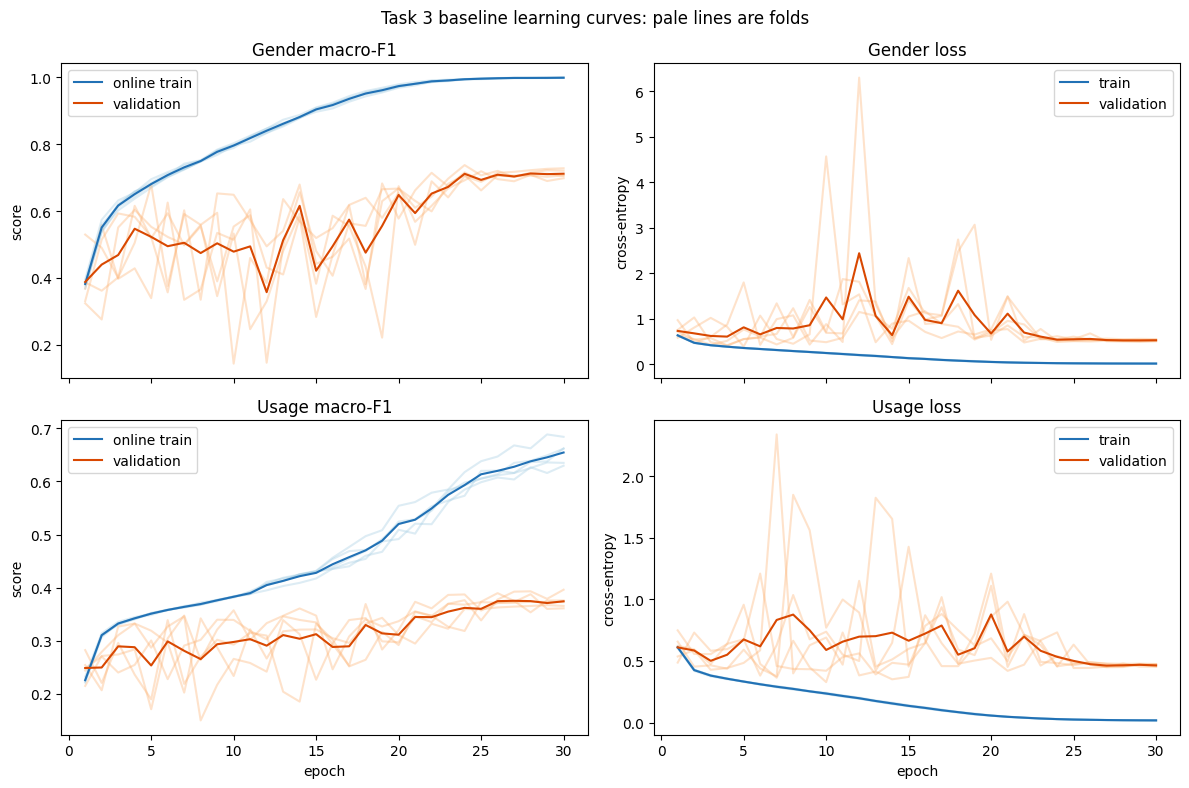

In [31]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_evidence[target]["history"]
    for fold, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="online train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} macro-F1")
    axes[row, 1].set_title(f"{target.title()} loss")
    axes[row, 0].set_ylabel("score")
    axes[row, 1].set_ylabel("cross-entropy")
    axes[row, 0].legend()
    axes[row, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("epoch")
fig.suptitle("Task 3 baseline learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()


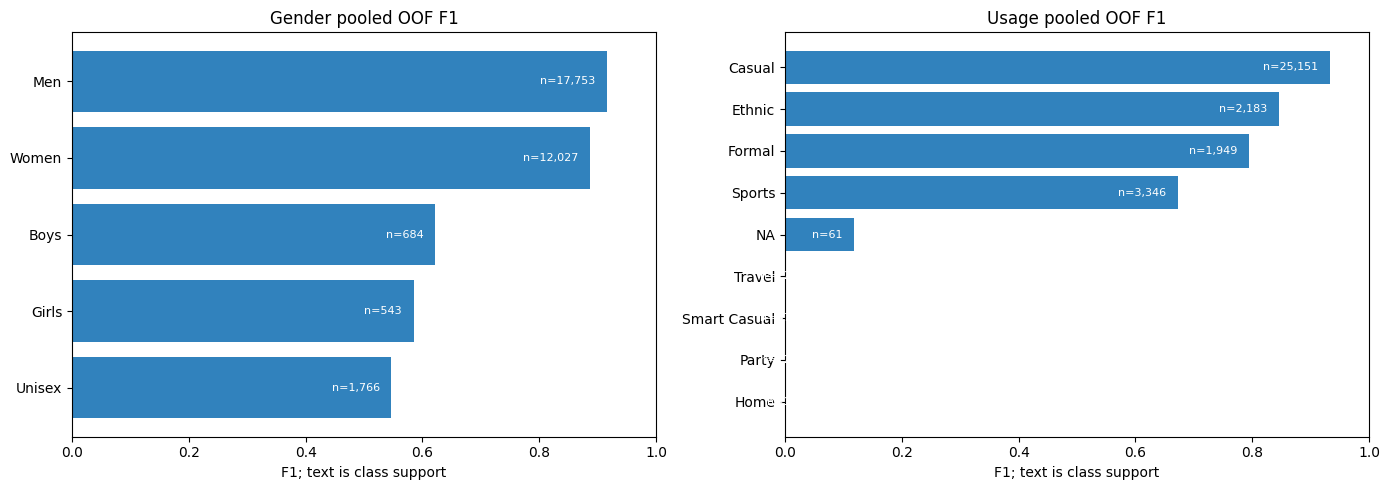

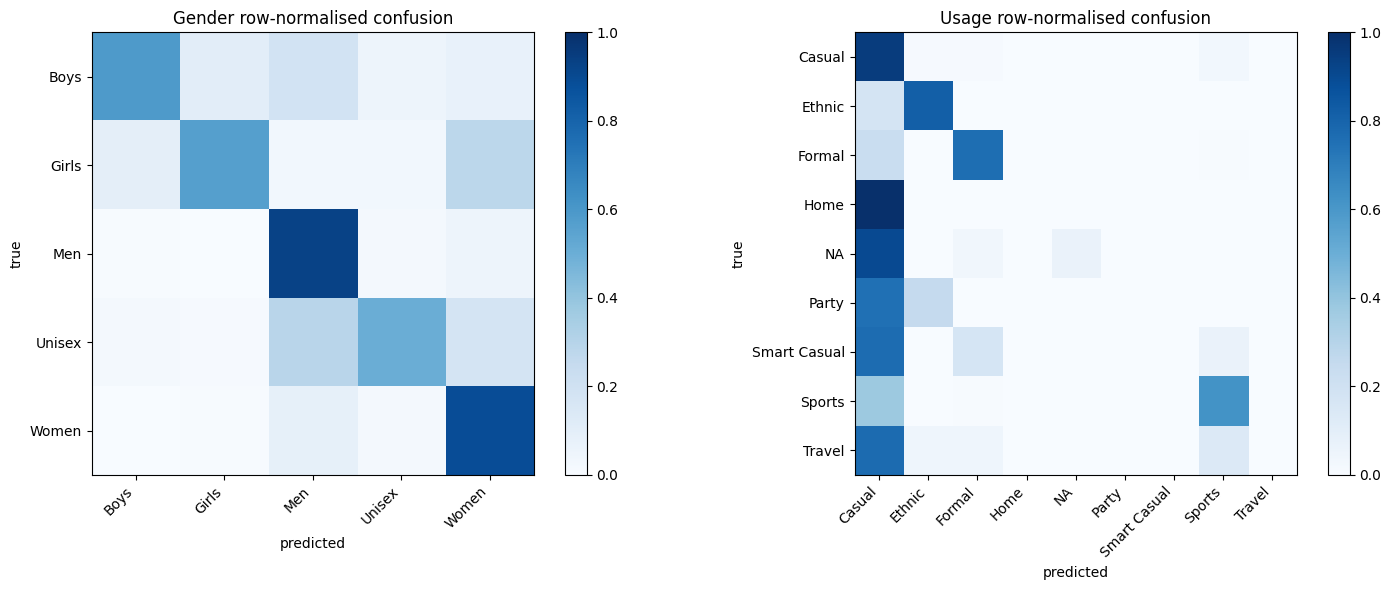

,target,corruption,mean,std
0,gender,brightness_085,-0.2562,0.0297
1,gender,brightness_115,-0.0386,0.0289
2,gender,grayscale,-0.0414,0.0090
3,gender,jpeg_75,-0.0416,0.0143
4,gender,translation_003,-0.1551,0.0029
5,usage,brightness_085,-0.0668,0.0290
6,usage,brightness_115,-0.0287,0.0124
7,usage,grayscale,-0.0135,0.0134
8,usage,jpeg_75,-0.0071,0.0149
9,usage,translation_003,-0.0642,0.0141


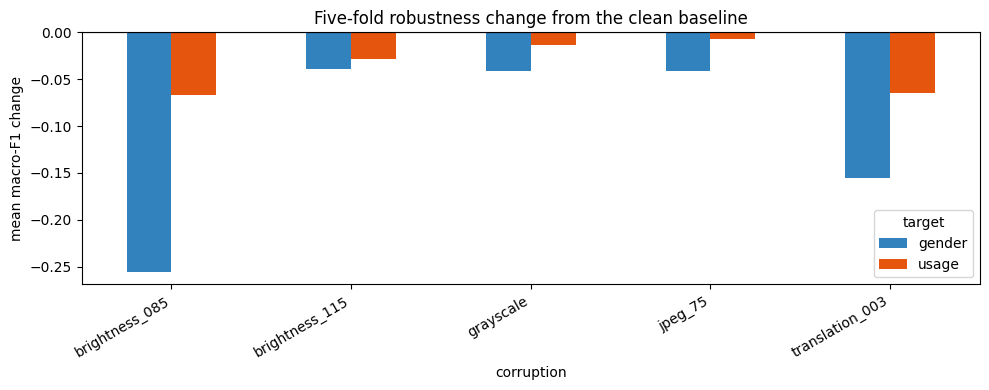

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = task3_evidence[target]["per_class"].sort_values("f1")
    bars = axis.barh(report["class_name"], report["f1"], color="#3182bd")
    axis.set_xlim(0, 1)
    axis.set_title(f"{target.title()} pooled OOF F1")
    axis.set_xlabel("F1; text is class support")
    for bar, support in zip(bars, report["support"], strict=True):
        axis.text(max(0.01, bar.get_width() - 0.02), bar.get_y() + bar.get_height()/2, f"n={support:,}", ha="right", va="center", color="white", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_per_class_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_evidence[target]["confusion"].to_numpy(dtype=float)
    normalised = np.divide(confusion, confusion.sum(axis=1, keepdims=True), out=np.zeros_like(confusion), where=confusion.sum(axis=1, keepdims=True) > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Blues")
    labels = task3_evidence[target]["confusion"].index.tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

robust_rows = []
for target, evidence in task3_evidence.items():
    grouped = evidence["robustness"].groupby("corruption")["macro_f1_change"].agg(["mean", "std"]).reset_index()
    grouped.insert(0, "target", target)
    robust_rows.append(grouped)
robustness_summary = pd.concat(robust_rows, ignore_index=True)
display(robustness_summary.round(4))
pivot = robustness_summary.pivot(index="corruption", columns="target", values="mean")
axis = pivot.plot.bar(figsize=(10, 4), color=["#3182bd", "#e6550d"])
axis.axhline(0, color="black", linewidth=0.8)
axis.set_ylabel("mean macro-F1 change")
axis.set_title("Five-fold robustness change from the clean baseline")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_robustness.png", dpi=180, bbox_inches="tight")
plt.show()


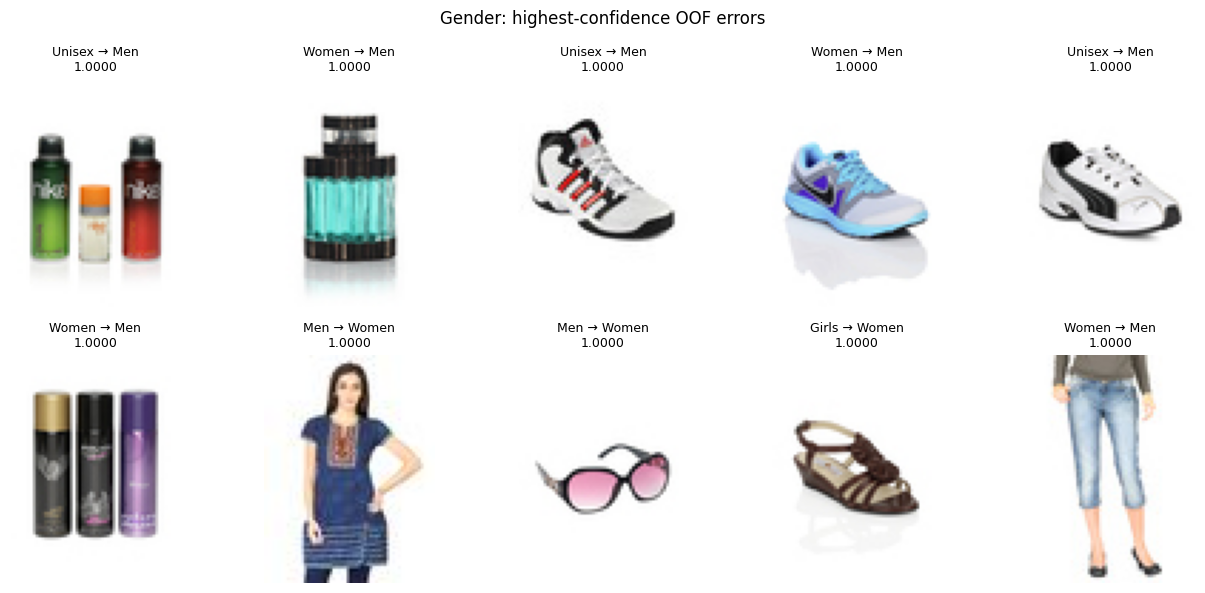

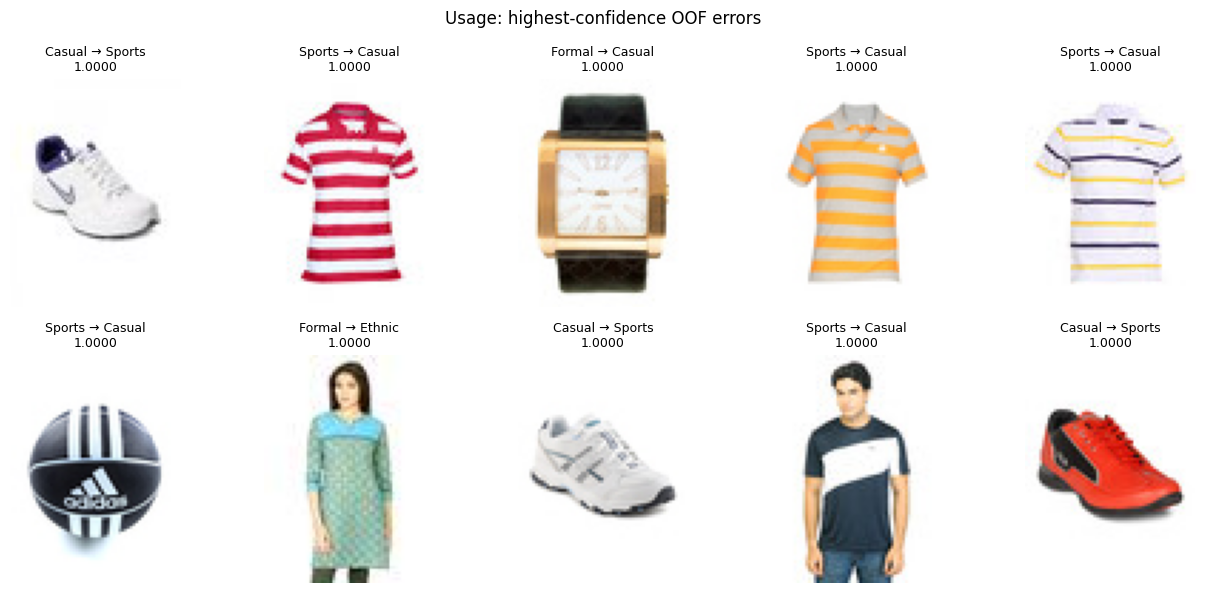

In [33]:
for target, evidence in task3_evidence.items():
    examples = (evidence["failures"]
        .query("selection_reason == 'high_confidence_error'")
        .sort_values("confidence", ascending=False)
        .head(10))
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    for axis, row in zip(axes.ravel(), examples.itertuples(index=False), strict=True):
        with Image.open(REPO_DIR / row.path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label}\n{row.confidence:.4f}", fontsize=9)
        axis.axis("off")
    fig.suptitle(f"{target.title()}: highest-confidence OOF errors")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"baseline_{target}_high_confidence_errors.png", dpi=180, bbox_inches="tight")
    plt.show()


## 8. Gender baseline diagnosis and next gate

**Decision: accept E1 as the reference parent, not as the final model.**

- Pooled OOF macro-F1 is **0.7118**. Fold scores are 0.6982, 0.7068, 0.7048,
  0.7207, and 0.7279: mean 0.7117, standard deviation 0.0109. The result is stable across
  the five family-safe folds.
- The final online training macro-F1 is about 0.999 in every fold while OOF stays near 0.71.
  Final training loss averages about 0.0107. This is strong memorisation evidence.
- Validation loss reaches its minimum at epochs 3–6, then rises, while the best validation
  macro-F1 arrives at epochs 24–30. Early stopping on loss would therefore hurt the frozen
  primary metric. The model becomes more certain before its minority decisions finish improving.
- Men F1 is 0.9167 and Women F1 is 0.8878. Boys, Girls, and Unisex are much weaker at
  0.6222, 0.5851, and 0.5470. Class support explains part, but not all, of this gap.
- The largest error routes are Women→Men (1,026), Men→Women (854), and Unisex→Men
  (516). Gender presentation is often weak or absent in product-only images.
- Mean macro-F1 change is −0.2562 under brightness ×0.85 and −0.1551 under a 3%
  translation. JPEG 75, grayscale, and brightness ×1.15 each cost about 0.04 or less.
- The selected 40 highest-confidence errors all have confidence at least 0.99. The gallery
  contains fragrances, watches, shoes, and other products with weak audience cues. Average
  ECE is only 0.0756, so the mean calibration score hides these extreme local mistakes.

The first eligible child changes only one factor: add mild random brightness during training.
Architecture, input size, loss, optimiser, schedule, seed, folds, and final-epoch rule stay fixed.
Class weighting, translation, more pixels, and a new architecture are not added to this child.


## 9. Usage baseline diagnosis and next gate

**Decision: accept E1 as the reference parent, not as the final model.**

- Pooled OOF macro-F1 is **0.3738**, or **0.4205** without the one-example Home class.
  Fold macro-F1 ranges from 0.3609 to 0.3960, with standard deviation 0.0121.
- Accuracy is 0.8930, but 25,151 of 32,772 valid rows (76.7%) are Casual. Accuracy and
  weighted-F1 mainly describe the large classes and hide rare-class failure.
- Casual, Ethnic, Formal, and Sports reach F1 values of 0.9329, 0.8463, 0.7939, and
  0.6731. NA reaches only 0.1176. Home, Party, Smart Casual, and Travel all score zero.
- The model predicts no Home, Party, or Smart Casual examples. It predicts Travel once,
  incorrectly. It sends 1,255 Sports, 450 Formal, 391 Ethnic, 55 NA, 36 Smart Casual,
  17 Travel, 9 Party, and the one Home row to Casual.
- Final training loss averages about 0.0177, but pooled OOF NLL is 0.4641. Validation loss
  bottoms at epochs 6–13 while the best macro-F1 appears at epochs 26–30. As with gender,
  loss-based early stopping would select the wrong model for the primary metric.
- Mean robustness drops are smaller than gender: −0.0668 for darkening and −0.0642 for
  translation. This does not make Usage strong; its clean macro-F1 is already low.
- The error gallery shows real visual overlap. Sports and Casual shirts or shoes can look
  alike, and business labels such as Formal, Party, and Travel are not always visible from
  one product image. Weighting cannot create missing visual information.

The first eligible child changes only the loss to capped class-balanced cross-entropy. It uses
effective-number weights with `beta=0.999`, mean-one nonzero normalisation, cap 5, and only
the current fold's training counts. `Home` does not select or judge the child. Architecture,
input, augmentation, optimiser, schedule, seed, folds, and checkpoint rule stay fixed.


## 10. First child evidence and decisions

The E2 rules were frozen before training. Like the baseline section, the saved outputs make the
results readable without rerunning Colab. The code reproduces the tables and figures from the
registered Drive artifacts and compares each child with its exact parent. These cells do not
train a model or read the final holdout.


In [ ]:
def load_child_evidence(target, artifact_dir, run_prefix):
    target_dir = DRIVE_TASK_DIR / artifact_dir / target
    aggregate_dir = target_dir / "aggregate"
    aggregate_files = ("metrics.json", "per_class.csv", "confusion_matrix.csv", "failure_index.csv")
    missing = [name for name in aggregate_files if not (aggregate_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Missing {target} child aggregate files: {missing}")

    latest_by_fold = {}
    for run_dir in sorted(target_dir.glob(f"{run_prefix}_{target}_smallcnn_f*")):
        required = [run_dir / name for name in ("config.json", "final_epoch.pt", "metrics.json", "history.csv", "robustness.csv")]
        if not all(path.is_file() for path in required):
            continue
        metrics = read_json(run_dir / "metrics.json")
        latest_by_fold[int(metrics["validation_fold"])] = {
            "run_dir": run_dir,
            "checkpoint": run_dir / "final_epoch.pt",
            "metrics": metrics,
        }
    if set(latest_by_fold) != set(range(5)):
        raise RuntimeError(f"Expected completed child folds 0-4 for {target}; found {sorted(latest_by_fold)}")

    histories = []
    robustness = []
    for fold, record in sorted(latest_by_fold.items()):
        histories.append(pd.read_csv(record["run_dir"] / "history.csv").assign(fold=fold))
        robustness.append(pd.read_csv(record["run_dir"] / "robustness.csv").assign(fold=fold))

    return {
        "aggregate_dir": aggregate_dir,
        "metrics": read_json(aggregate_dir / "metrics.json"),
        "per_class": pd.read_csv(aggregate_dir / "per_class.csv", keep_default_na=False),
        "confusion": pd.read_csv(aggregate_dir / "confusion_matrix.csv", index_col=0, keep_default_na=False),
        "failures": pd.read_csv(aggregate_dir / "failure_index.csv", keep_default_na=False),
        "folds": latest_by_fold,
        "history": pd.concat(histories, ignore_index=True),
        "robustness": pd.concat(robustness, ignore_index=True),
    }


task3_child_evidence = {
    "gender": load_child_evidence(
        "gender", "experiments/t3_gender_e2_brightness", "t3_gender_e2_brightness"
    ),
    "usage": load_child_evidence(
        "usage", "experiments/t3_usage_e2_class_balanced_ce", "t3_usage_e2_class_balanced_ce"
    ),
}
print("Loaded completed E2 evidence for gender and usage from Drive.")


Loaded completed E2 evidence for gender and usage from Drive.


In [ ]:
comparison_rows = []
for target in ("gender", "usage"):
    parent = task3_evidence[target]["metrics"]
    child = task3_child_evidence[target]["metrics"]
    metric_names = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "nll", "ece_15"]
    if target == "usage":
        metric_names.append("macro_f1_without_home")
    for metric in metric_names:
        comparison_rows.append({
            "target": target,
            "metric": metric,
            "parent": parent[metric],
            "child": child[metric],
            "change": child[metric] - parent[metric],
        })
comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(4))

class_rows = []
for target in ("gender", "usage"):
    parent = task3_evidence[target]["per_class"].set_index("class_name")
    child = task3_child_evidence[target]["per_class"].set_index("class_name")
    for class_name in parent.index:
        class_rows.append({
            "target": target,
            "class_name": class_name,
            "support": int(parent.loc[class_name, "support"]),
            "parent_f1": parent.loc[class_name, "f1"],
            "child_f1": child.loc[class_name, "f1"],
            "f1_change": child.loc[class_name, "f1"] - parent.loc[class_name, "f1"],
        })
class_comparison = pd.DataFrame(class_rows)
display(class_comparison.round(4))

robustness_rows = []
for target in ("gender", "usage"):
    parent = task3_evidence[target]["robustness"].groupby("corruption")["macro_f1_change"].mean()
    child = task3_child_evidence[target]["robustness"].groupby("corruption")["macro_f1_change"].mean()
    for corruption in parent.index:
        robustness_rows.append({
            "target": target,
            "corruption": corruption,
            "parent_change": parent[corruption],
            "child_change": child[corruption],
            "improvement": child[corruption] - parent[corruption],
        })
robustness_comparison = pd.DataFrame(robustness_rows)
display(robustness_comparison.round(4))

gate_table = pd.DataFrame([
    {"target": "gender", "gate": "pooled macro-F1 >= 0.7218", "observed": task3_child_evidence["gender"]["metrics"]["macro_f1"], "passed": task3_child_evidence["gender"]["metrics"]["macro_f1"] >= 0.7218},
    {"target": "usage", "gate": "pooled macro-F1 >= 0.3938", "observed": task3_child_evidence["usage"]["metrics"]["macro_f1"], "passed": task3_child_evidence["usage"]["metrics"]["macro_f1"] >= 0.3938},
    {"target": "usage", "gate": "macro-F1 without Home >= 0.4405", "observed": task3_child_evidence["usage"]["metrics"]["macro_f1_without_home"], "passed": task3_child_evidence["usage"]["metrics"]["macro_f1_without_home"] >= 0.4405},
])
display(gate_table.round(4))


    target                 metric  parent   child  change
0   gender               accuracy  0.8768  0.8730 -0.0038
1   gender      balanced_accuracy  0.6933  0.6767 -0.0166
2   gender               macro_f1  0.7118  0.6989 -0.0129
3   gender            weighted_f1  0.8745  0.8707 -0.0038
4   gender                    nll  0.5237  0.5041 -0.0197
5   gender                 ece_15  0.0756  0.0750 -0.0007
6    usage               accuracy  0.8930  0.8915 -0.0015
7    usage      balanced_accuracy  0.3571  0.3826  0.0255
8    usage               macro_f1  0.3738  0.4082  0.0344
9    usage            weighted_f1  0.8885  0.8876 -0.0009
10   usage                    nll  0.4641  0.3428 -0.1213
11   usage                 ece_15  0.0672  0.0331 -0.0341
12   usage  macro_f1_without_home  0.4205  0.4592  0.0387

    target    class_name  support  parent_f1  child_f1  f1_change
0   gender          Boys      684     0.6222    0.5980    -0.0242
1   gender         Girls      543     0.5851    0.5425    -0.0426
2   gender           Men    17753     0.9167    0.9141    -0.0027
3   gender        Unisex     1766     0.5470    0.5568     0.0098
4   gender         Women    12027     0.8878    0.8831    -0.0046
5    usage        Casual    25151     0.9329    0.9318    -0.0011
6    usage        Ethnic     2183     0.8463    0.8540     0.0077
7    usage        Formal     1949     0.7939    0.7759    -0.0180
8    usage          Home        1     0.0000    0.0000     0.0000
9    usage            NA       61     0.1176    0.2299     0.1122
10   usage         Party       12     0.0000    0.0000     0.0000
11   usage  Smart Casual       47     0.0000    0.0000     0.0000
12   usage        Sports     3346     0.6731    0.6751     0.0020
13   usage        Travel       22     0.0000    0.2069     0.2069

   target                   gate  threshold  observed  passed
0  gender        pooled macro-F1     0.7218    0.6989   False
1   usage        pooled macro-F1     0.3938    0.4082    True
2   usage  macro-F1 without Home     0.4405    0.4592    True

In [ ]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_child_evidence[target]["history"]
    for fold, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="online train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} E2 macro-F1")
    axes[row, 1].set_title(f"{target.title()} E2 loss")
    axes[row, 0].set_ylabel("score")
    axes[row, 1].set_ylabel("cross-entropy")
    axes[row, 0].legend()
    axes[row, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("epoch")
fig.suptitle("Task 3 E2 learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
fold_rows = []
for target in ("gender", "usage"):
    for fold in range(5):
        parent = task3_evidence[target]["folds"][fold]["metrics"]["macro_f1"]
        child = task3_child_evidence[target]["folds"][fold]["metrics"]["macro_f1"]
        fold_rows.append({"target": target, "fold": fold, "parent_macro_f1": parent, "child_macro_f1": child, "change": child - parent})
fold_comparison = pd.DataFrame(fold_rows)
display(fold_comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_macro_f1"], 0.36, label="parent", color="#9ecae1")
    axis.bar(x + 0.18, part["child_macro_f1"], 0.36, label="E2 child", color="#fdae6b")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} final validation macro-F1")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_fold_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = class_comparison.query("target == @target").sort_values("parent_f1")
    y = np.arange(len(report))
    axis.barh(y - 0.18, report["parent_f1"], 0.36, label="parent", color="#9ecae1")
    axis.barh(y + 0.18, report["child_f1"], 0.36, label="E2 child", color="#fdae6b")
    axis.set_yticks(y, report["class_name"].astype(str))
    axis.set_xlim(0, 1)
    axis.set_xlabel("pooled OOF F1")
    axis.set_title(f"{target.title()} class comparison")
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_per_class_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_child_evidence[target]["confusion"].to_numpy(dtype=float)
    row_totals = confusion.sum(axis=1, keepdims=True)
    normalised = np.divide(confusion, row_totals, out=np.zeros_like(confusion), where=row_totals > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Oranges")
    labels = task3_child_evidence[target]["confusion"].index.astype(str).tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} E2 row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = robustness_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_change"], 0.36, label="parent", color="#9ecae1")
    axis.bar(x + 0.18, part["child_change"], 0.36, label="E2 child", color="#fdae6b")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(x, part["corruption"], rotation=30, ha="right")
    axis.set_title(f"{target.title()} robustness")
    axis.legend()
axes[0].set_ylabel("mean macro-F1 change from clean")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_robustness_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
for target, evidence in task3_child_evidence.items():
    examples = (evidence["failures"]
        .query("selection_reason == 'high_confidence_error'")
        .sort_values("confidence", ascending=False)
        .head(10))
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    for axis, row in zip(axes.ravel(), examples.itertuples(index=False), strict=True):
        with Image.open(REPO_DIR / row.path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label}\n{row.confidence:.4f}", fontsize=9)
        axis.axis("off")
    fig.suptitle(f"{target.title()} E2: highest-confidence OOF errors")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"e2_{target}_high_confidence_errors.png", dpi=180, bbox_inches="tight")
    plt.show()


### Saved E2 figures

The plotting cells above reproduce these figures from the registered Drive artifacts.

![E2 learning curves](../results/figures/task3/e2_learning_curves.png)

![Parent and E2 fold comparison](../results/figures/task3/e2_fold_macro_f1.png)

![Parent and E2 per-class comparison](../results/figures/task3/e2_per_class_f1_comparison.png)

![E2 normalised confusion matrices](../results/figures/task3/e2_normalised_confusion.png)


### Gender E2 — reject brightness augmentation

Gender E2 reached **0.6989 pooled macro-F1**, down **0.0129** from 0.7118. It missed
the frozen 0.7218 gate by 0.0229. Accuracy fell from 0.8768 to 0.8730 and balanced
accuracy fell from 0.6933 to 0.6767. Final fold macro-F1 values were 0.7279, 0.6774,
0.6740, 0.7260, and 0.6889. Their standard deviation was 0.0263, compared with 0.0109
for E1, so the child was also less stable across folds.
The fold plot makes the instability visible: E2 improves folds 0 and 3, but loses on folds 1,
2, and 4. Its learning curves still drive training macro-F1 close to 1.0 while validation stays
near 0.70 and moves sharply between epochs. Brightness did not reduce memorisation.

| Class | E1 F1 | E2 F1 | Change |
|---|---:|---:|---:|
| Boys | 0.6222 | 0.5980 | -0.0242 |
| Girls | 0.5851 | 0.5425 | -0.0426 |
| Men | 0.9167 | 0.9141 | -0.0026 |
| Unisex | 0.5470 | 0.5568 | +0.0098 |
| Women | 0.8878 | 0.8831 | -0.0047 |

The common-class guard passed, but the primary gate did not. Boys and Girls lost more than
Unisex gained. Even if the robustness table shows better dark-image behaviour, the rule required
both robustness and clean macro-F1. Random brightness therefore changes the input without fixing
the main generalisation error. **E2 is rejected and E1 remains the Gender parent.**

### Usage E2 — accept class-balanced cross-entropy

Usage E2 reached **0.4082 pooled macro-F1**, up **0.0344** from 0.3738, and reached
**0.4592 without Home**, up **0.0387** from 0.4205. Both frozen gates passed. Balanced
accuracy improved from 0.3571 to 0.3826 while ordinary accuracy moved only from 0.8930
to 0.8915. This is the intended trade: better treatment of supported minority classes with
almost no loss on the majority-dominated accuracy.

Calibration also improved: NLL fell from 0.4641 to 0.3428 and ECE fell from 0.0672 to
0.0331. Final fold macro-F1 values were 0.4086, 0.3818, 0.4362, 0.3999, and 0.3950.
Their standard deviation was 0.0203, higher than E1's 0.0121, so the gain is useful but
not equally strong in every fold.
The fold plot shows improvement in four of five folds; only fold 4 is effectively flat. The
learning curves still show a large train-validation gap, but validation macro-F1 rises more
consistently than Gender. This supports keeping the new loss while testing one small
regularisation change next.

| Class | E1 F1 | E2 F1 | Change |
|---|---:|---:|---:|
| Casual | 0.9329 | 0.9318 | -0.0011 |
| Ethnic | 0.8463 | 0.8540 | +0.0077 |
| Formal | 0.7939 | 0.7759 | -0.0180 |
| Home | 0.0000 | 0.0000 | 0.0000 |
| NA | 0.1176 | 0.2299 | +0.1123 |
| Party | 0.0000 | 0.0000 | 0.0000 |
| Smart Casual | 0.0000 | 0.0000 | 0.0000 |
| Sports | 0.6731 | 0.6751 | +0.0020 |
| Travel | 0.0000 | 0.2069 | +0.2069 |

Casual stayed flat and Sports improved, so the no-harm guard passed. The largest gains came
from NA and Travel, but Party, Smart Casual, and the one-row Home class remain unlearned.
Formal also fell by 0.0180. Weighting helped the classes that had some learnable evidence; it
could not invent evidence for tiny classes or remove semantic overlap. **E2 is accepted as the
new Usage parent, but not yet declared final.** The confusion plot confirms the remaining
failure: Home, Party, and Smart Casual still collapse mostly into Casual; Travel is detected only
three times and NA only ten times.


## 11. Next hypotheses

These proposals and gates are frozen before another run. `E1`, `E2`, and `E3` below are
sequential experiment labels, not the research document's evidence-level names. A rejected
change is not stacked: Gender E3 starts from E1. Usage E3 starts from accepted E2.

### Gender E3 hypothesis: mildly weight the supported minority classes

Brightness augmentation did not close the generalisation gap and hurt Boys and Girls. E1 still
has strong support imbalance: Men and Women dominate, while Boys, Girls, and Unisex have mean
F1 0.5848. Usage E2 shows that this loss can help another target, but it does not prove that it
will help Gender. The cap is a safety bound; the largest expected fold weight is only about 1.66.

| Pre-training decision | Frozen value |
|---|---|
| Parent | Gender E1 baseline; do not inherit brightness augmentation |
| One change | Effective-number class-balanced cross-entropy only: `beta=0.999`, mean-one present-class weights, cap `5.0` |
| Everything kept fixed | SmallCNN, `80×60` input, no augmentation, optimiser, schedule, 30 epochs, seed, folds, final checkpoint |
| Primary success gates | Pooled OOF macro-F1 ≥ 0.7218; mean Boys/Girls/Unisex F1 ≥ 0.6048 |
| Paired uncertainty gate | In a fixed 10,000-sample product-family bootstrap, the 95% interval for macro-F1 change is entirely above zero |
| Class no-harm gates | Men F1 ≥ 0.8967; Women F1 ≥ 0.8678; no class has zero recall; each minority predicted count ≤ 1.5× its support |
| Stability and calibration gates | Fold macro-F1 SD ≤ 0.0209; NLL ≤ 0.5437; ECE-15 ≤ 0.0856 |
| Robustness gate | For every tested corruption, mean macro-F1 change is no more than 0.02 worse than E1 |
| Written before training | Yes |
| Current state | Proposed; not trained |

### Usage E3 hypothesis: test mild classifier regularisation

E2 is the accepted parent. Its online training score is much higher than validation, which
suggests overfitting but does not prove the final model memorised the fold. E3 therefore adds
dropout only after global pooling and before the final linear classifier. Finished-model training
metrics will be measured in evaluation mode before making a memorisation claim.

| Pre-training decision | Frozen value |
|---|---|
| Parent | Accepted Usage E2 class-balanced SmallCNN |
| One change | Dropout `p=0.20` after global pooling and before the final linear classifier |
| Everything kept fixed | SmallCNN channels, `80×60` input, E2 loss and weights, no augmentation, optimiser, schedule, 30 epochs, seed, folds, final checkpoint |
| Primary success gates | Pooled OOF macro-F1 ≥ 0.4182; macro-F1 without Home ≥ 0.4692 |
| Paired uncertainty gate | In a fixed 10,000-sample product-family bootstrap, the 95% interval for macro-F1 change is entirely above zero |
| Overall no-harm gate | Accuracy ≥ 0.8815 |
| Class no-harm gates | Casual F1 ≥ 0.9018; Ethnic ≥ 0.8240; Formal ≥ 0.7459; Sports ≥ 0.6451 |
| Minority gates | Mean NA/Travel F1 ≥ 0.1984 and both classes retain non-zero recall |
| Stability and calibration gates | Fold macro-F1 SD ≤ 0.0303; NLL ≤ 0.3628; ECE-15 ≤ 0.0431 |
| Robustness gate | For every tested corruption, mean macro-F1 change is no more than 0.02 worse than E2 |
| Written before training | Yes |
| Current state | Proposed; not trained |

Both next runs keep SmallCNN. A quality-driven architecture test opens only after three seeds
show real underfitting: finished-model train/validation macro-F1 gap ≤ 0.05 in at least four
folds, absolute last-five validation slope < 0.002 per epoch, low training performance, and
errors with learnable image structure rather than tiny support or label ambiguity. The first
architecture candidate would be a scratch low-resolution ResNet-18 with a `3×3` stride-one stem
and no early max-pool. One failed E3 run is not enough to open that test.


## 12. Sequential experiment and decision ledger

This table grows one approved row at a time. Do not fill a model matrix in advance.

| Hypothesis | Target | Parent run IDs | One changed factor | Child run IDs | Evidence bundle | Decision | Accepted parent |
|---|---|---|---|---|---|---|---|
| Baseline contract | gender | none | primary small CNN | five completed folds | `task3/baseline/gender` | accept as reference, not final | E1 gender |
| Baseline contract | usage | none | primary small CNN | five completed folds | `task3/baseline/usage` | accept as reference, not final | E1 usage |
| E2 brightness | gender | E1 gender fold IDs | brightness augmentation only | five completed registered folds | `task3/experiments/t3_gender_e2_brightness/gender` | reject: macro-F1 fell 0.0129 | E1 gender |
| E2 class-balanced CE | usage | E1 usage fold IDs | loss weights only | five completed registered folds | `task3/experiments/t3_usage_e2_class_balanced_ce/usage` | accept: both frozen gates passed | E2 usage |
| E3 class-balanced CE | gender | E1 gender fold IDs | loss weights only | not run | hypothesis above | awaiting approval | E1 gender |
| E3 classifier dropout | usage | E2 usage fold IDs | dropout `p=0.20` only | not run | hypothesis above | awaiting approval | E2 usage |

Decision values are `accept`, `reject`, or `stop`. A rejected child's change is not stacked
into the next run. Every number shown here must be generated from registered artifacts.


## 13. Conditional sharing and pretrained comparison

A shared two-head model is not automatic. Open it only when accepted separate parents exist,
their combined measured cost fails a named limit, a matched common backbone is possible, and the
one-point no-harm margin is frozen first. Compare negative transfer separately for gender and
usage. Sharing changes only the task structure.

One ImageNet-pretrained ResNet-18 benchmark may run only after eligible selection is fixed. Mark
`scratch=false` and every submission, official-prediction, and application eligibility field
false. It cannot become a parent or change the eligible winner.


## 14. Implementation order and run registry

The reusable baseline path is now implemented in `src/fashion/train/`:

1. `registry.py` appends one durable row before the first optimiser step and preserves failures;
2. `data.py` enforces the saved folds, target mask, fold-only RGB statistics, and corruptions;
3. `model.py` contains the exact scratch SmallCNN and its gated classifier-dropout option;
4. `metrics.py` keeps the fixed class order, including zero-support classes;
5. `task3_baseline.py` writes curves, OOF predictions, per-class metrics, confusion, failures,
   core robustness, checkpoint, runtime, and cost artifacts;
6. `augmentation.py` contains the rejected brightness-only E2 transform;
7. `task3_experiments.py` locks child lineage and prevents extra factors from changing.

`04a_task3_smallcnn_baseline_training.ipynb` reproduces only the SmallCNN baseline.
`04b_task3_smallcnn_child_experiments.ipynb` loads those saved parents and trains only E2.
`04c_task3_smallcnn_e3_experiments.ipynb` loads the accepted E1/E2 parents and trains only E3.
This main notebook reads artifacts for analysis; it does not start training.
Both five-fold runners reject partial fold lists. Lower bounds and the classical
reference remain separate comparison stages and do not alter this primary CNN configuration.

Every training execution appends through `fashion.train.registry` to repository
`results/runs.csv` before its first optimiser step. Drive folders may mirror large artifacts,
but they do not replace the canonical registry. Notebook cells call shared code; they do not
contain a second training implementation.


## 15. Finalist judgement and decision log

Confirm only the accepted final parent for each target, plus a shared candidate only if its cost
gate opened and it passed. Use all five folds and three fixed seeds with every method choice frozen.

| Final decision | Accepted chain | Rejected children and reasons | Seed evidence | Class/failure evidence | Robustness/cost | Limitation | Date/owner |
|---|---|---|---|---|---|---|---|
| Gender | TODO | TODO | TODO | TODO | TODO | TODO | TODO |
| Usage | TODO | TODO | TODO | TODO | TODO | TODO | TODO |
| Separate or shared system | TODO | TODO | TODO | TODO | TODO | TODO | TODO |

Do not rewrite earlier decisions after holdout access.


## 16. Handoff to final evaluation

Before Notebook 06, provide:

- accepted parent-child chain and rejected hypotheses: TODO(owner)
- frozen winning eligible run ID(s): TODO(owner)
- frozen preprocessing, model, loss, optimiser, schedule, and seed rules: TODO(owner)
- frozen metrics, thresholds, and five-fold/three-seed evidence: TODO(owner)
- final all-development scratch-refit procedure: TODO(owner)
- expected checkpoint, calibration, registry, and official-output paths: TODO(owner)
- shared-model gate result or recorded reason it was not opened: TODO(owner)
- unresolved risks, weak classes, and honest limitations: TODO(owner)

**Handoff status: NOT READY — owner must complete every item above.**
